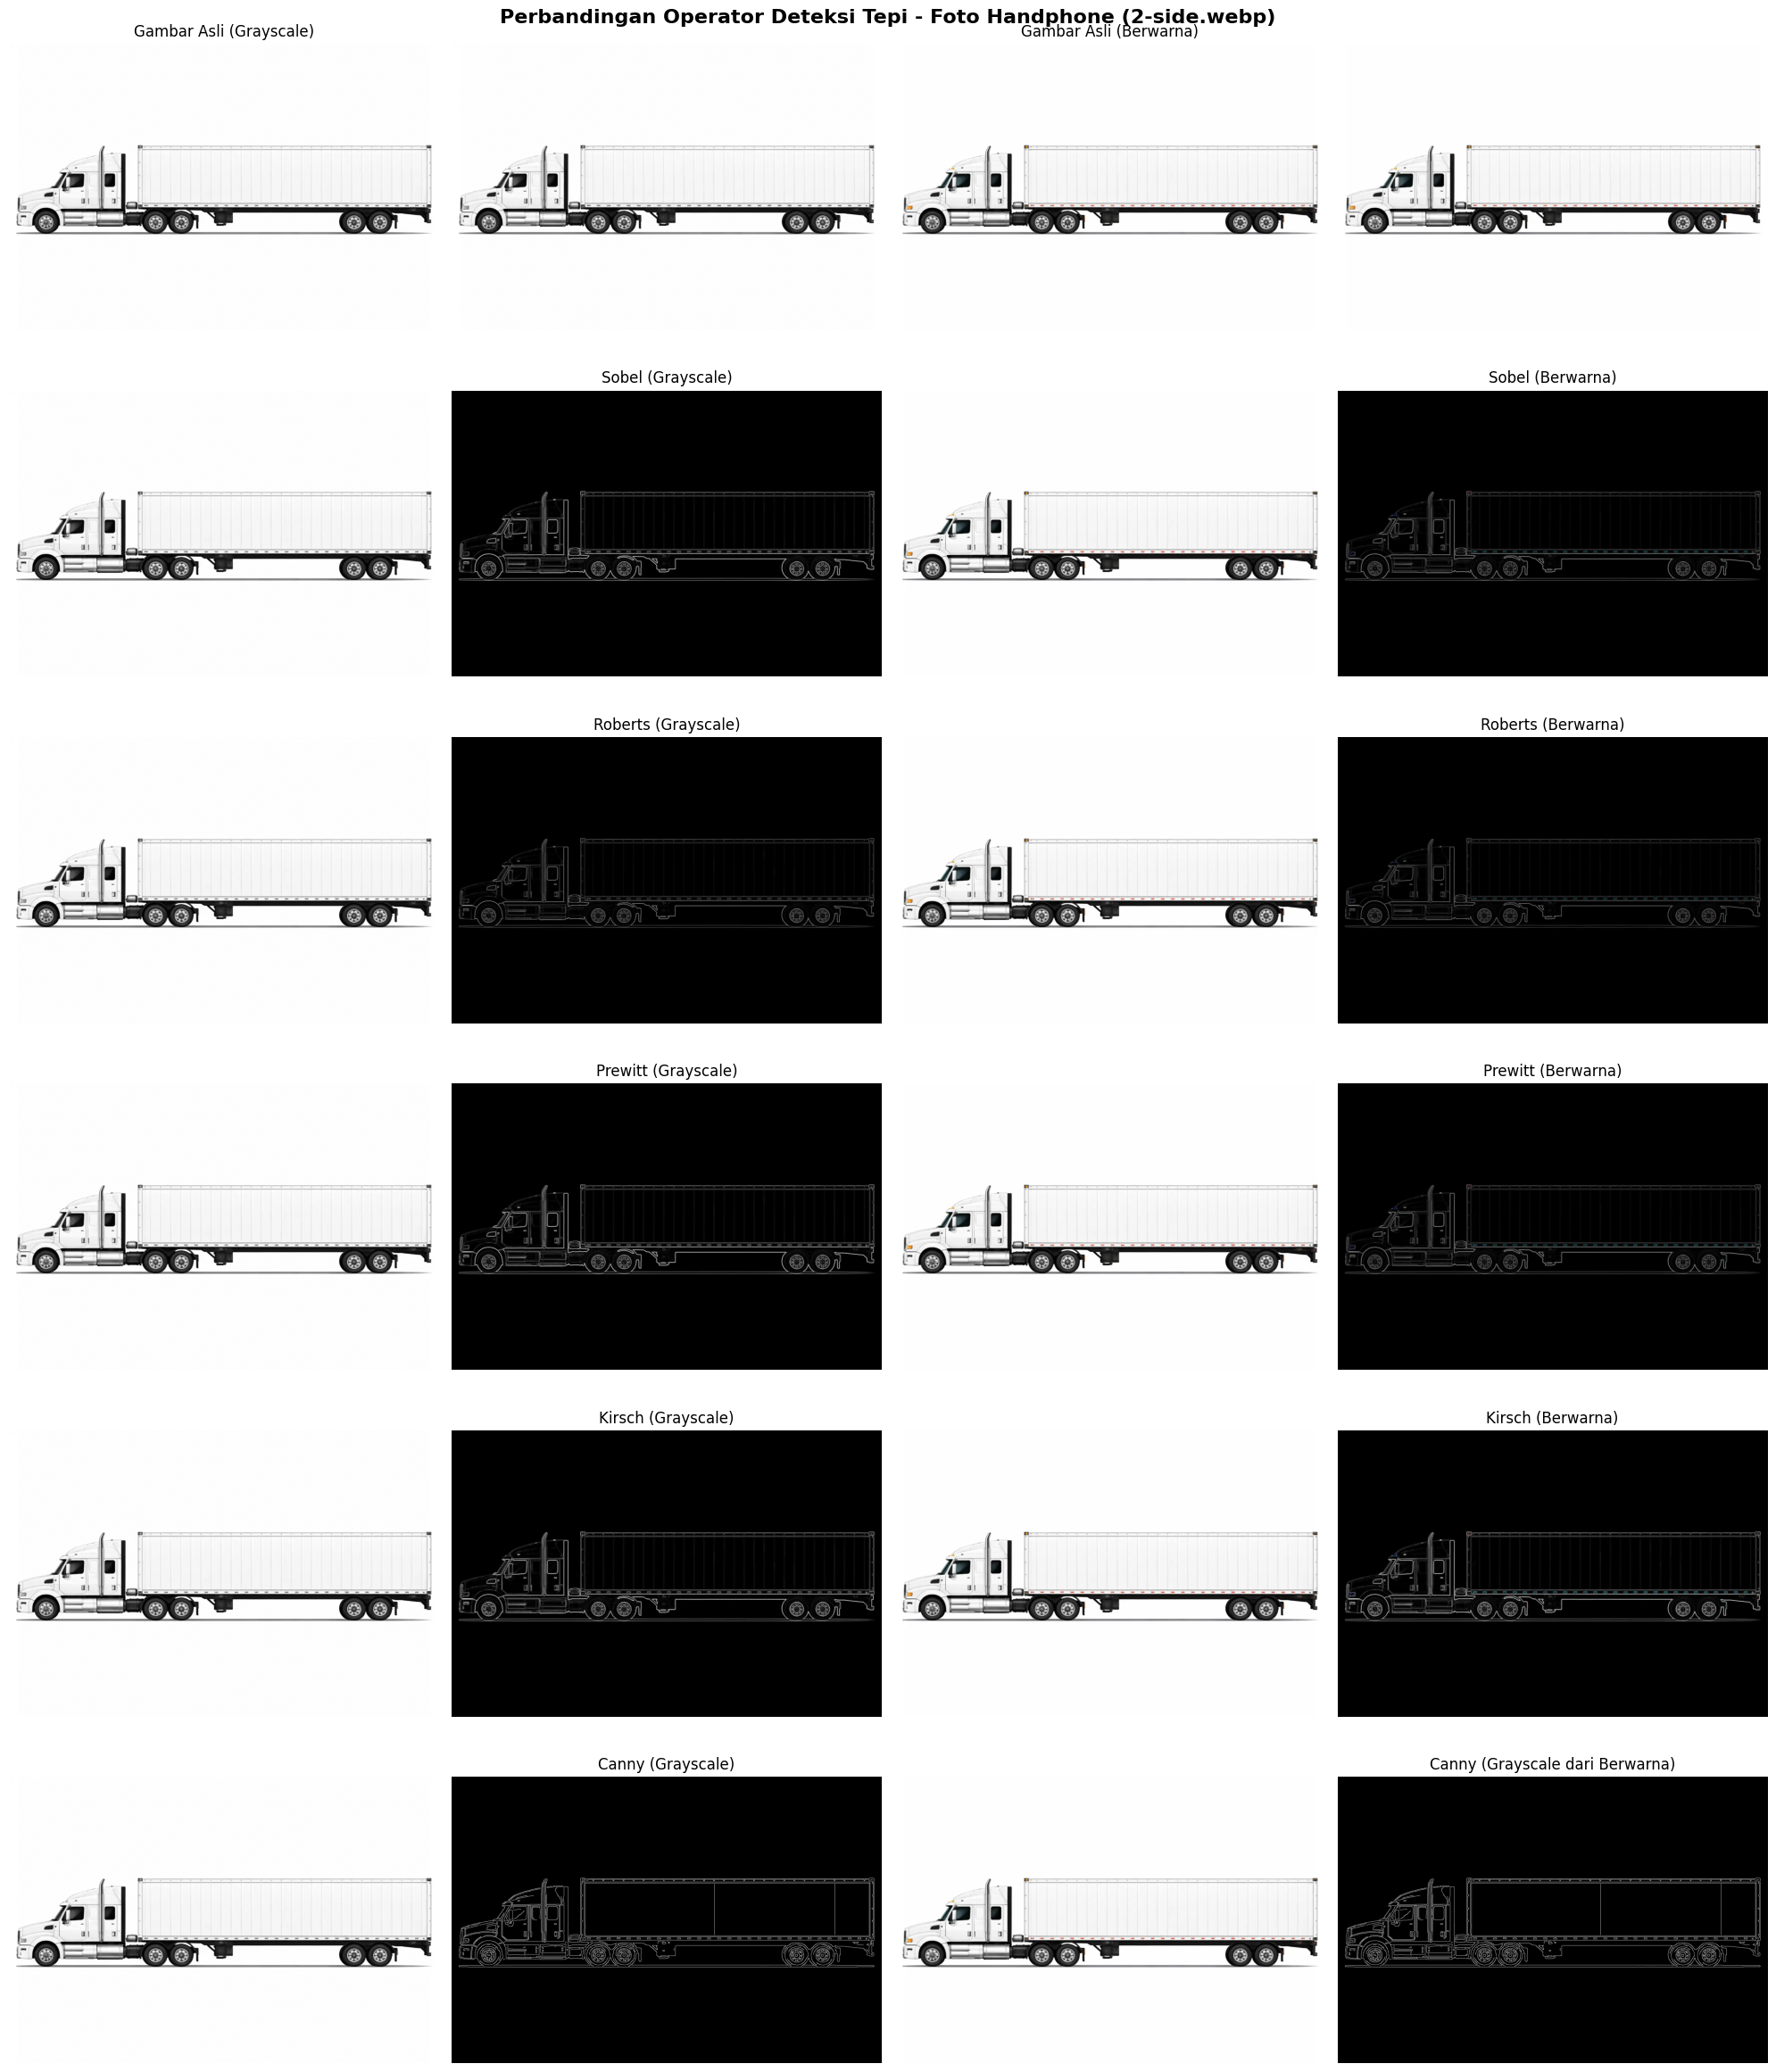

Rata-rata kekuatan tepi (grayscale):
- Sobel   : 0.012873
- Roberts : 0.010146
- Prewitt : 0.012817
- Kirsch  : 4.851098
- Canny   : 0.019813


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io, color, filters, feature, util
from skimage.filters.rank import gradient
from skimage.morphology import disk

# ===================== MUAT GAMBAR DARI HANDPHONE =====================
candidate_paths = [
    Path("2-side.webp"),
    Path("jobsheet2/2-side.webp"),
    Path.cwd() / "2-side.webp",
    Path.cwd() / "jobsheet2" / "2-side.webp",
]

image_path = next((path for path in candidate_paths if path.exists()), None)
if image_path is None:
    raise FileNotFoundError("File 2-side.webp tidak ditemukan. Pastikan file ada di folder jobsheet2.")

image_raw = io.imread(image_path)

# Pastikan citra dalam format RGB
if image_raw.ndim == 2:
    image_color = color.gray2rgb(image_raw)
elif image_raw.shape[2] == 4:
    image_color = color.rgba2rgb(image_raw)
else:
    image_color = image_raw

image_gray = color.rgb2gray(image_color)
image_gray_uint8 = util.img_as_ubyte(image_gray)

# ===================== OPERATOR DETEKSI TEPI =====================
def apply_edge_detection_rgb(image, operator):
    channels = [operator(image[:, :, i]) for i in range(3)]
    return np.stack(channels, axis=2)

sobel_gray = filters.sobel(image_gray)
roberts_gray = filters.roberts(image_gray)
prewitt_gray = filters.prewitt(image_gray)
kirsch_gray = gradient(image_gray_uint8, disk(1))
canny_gray = feature.canny(image_gray, sigma=1.2)

sobel_color = apply_edge_detection_rgb(image_color, filters.sobel)
roberts_color = apply_edge_detection_rgb(image_color, filters.roberts)
prewitt_color = apply_edge_detection_rgb(image_color, filters.prewitt)
kirsch_color = apply_edge_detection_rgb(
    image_color,
    lambda channel: gradient(util.img_as_ubyte(channel), disk(1))
)
canny_from_color = feature.canny(color.rgb2gray(image_color), sigma=1.2)

# ===================== VISUALISASI PERBANDINGAN =====================
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
ax = axes.ravel()

# Baris 1: gambar asli
ax[0].imshow(image_gray, cmap="gray")
ax[0].set_title("Gambar Asli (Grayscale)")
ax[0].axis("off")

ax[1].imshow(image_gray, cmap="gray")
ax[1].axis("off")

ax[2].imshow(image_color)
ax[2].set_title("Gambar Asli (Berwarna)")
ax[2].axis("off")

ax[3].imshow(image_color)
ax[3].axis("off")

# Baris 2: Sobel
ax[4].imshow(image_gray, cmap="gray")
ax[4].axis("off")

ax[5].imshow(sobel_gray, cmap="gray")
ax[5].set_title("Sobel (Grayscale)")
ax[5].axis("off")

ax[6].imshow(image_color)
ax[6].axis("off")

ax[7].imshow(sobel_color)
ax[7].set_title("Sobel (Berwarna)")
ax[7].axis("off")

# Baris 3: Roberts
ax[8].imshow(image_gray, cmap="gray")
ax[8].axis("off")

ax[9].imshow(roberts_gray, cmap="gray")
ax[9].set_title("Roberts (Grayscale)")
ax[9].axis("off")

ax[10].imshow(image_color)
ax[10].axis("off")

ax[11].imshow(roberts_color)
ax[11].set_title("Roberts (Berwarna)")
ax[11].axis("off")

# Baris 4: Prewitt
ax[12].imshow(image_gray, cmap="gray")
ax[12].axis("off")

ax[13].imshow(prewitt_gray, cmap="gray")
ax[13].set_title("Prewitt (Grayscale)")
ax[13].axis("off")

ax[14].imshow(image_color)
ax[14].axis("off")

ax[15].imshow(prewitt_color)
ax[15].set_title("Prewitt (Berwarna)")
ax[15].axis("off")

# Baris 5: Kirsch
ax[16].imshow(image_gray, cmap="gray")
ax[16].axis("off")

ax[17].imshow(kirsch_gray, cmap="gray")
ax[17].set_title("Kirsch (Grayscale)")
ax[17].axis("off")

ax[18].imshow(image_color)
ax[18].axis("off")

ax[19].imshow(kirsch_color)
ax[19].set_title("Kirsch (Berwarna)")
ax[19].axis("off")

# Baris 6: Canny
ax[20].imshow(image_gray, cmap="gray")
ax[20].axis("off")

ax[21].imshow(canny_gray, cmap="gray")
ax[21].set_title("Canny (Grayscale)")
ax[21].axis("off")

ax[22].imshow(image_color)
ax[22].axis("off")

ax[23].imshow(canny_from_color, cmap="gray")
ax[23].set_title("Canny (Grayscale dari Berwarna)")
ax[23].axis("off")

plt.suptitle("Perbandingan Operator Deteksi Tepi - Foto Handphone (2-side.webp)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Ringkasan kekuatan tepi rata-rata pada citra grayscale
edge_strength = {
    "Sobel": np.mean(sobel_gray),
    "Roberts": np.mean(roberts_gray),
    "Prewitt": np.mean(prewitt_gray),
    "Kirsch": np.mean(kirsch_gray),
    "Canny": np.mean(canny_gray.astype(float)),
}

print("Rata-rata kekuatan tepi (grayscale):")
for name, value in edge_strength.items():
    print(f"- {name:8s}: {value:.6f}")